# EN3160 Assignment 01: Intensity Transformations and Neighborhood Filtering

GUNATHUNGA U.A. - 230218G

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Question 1 

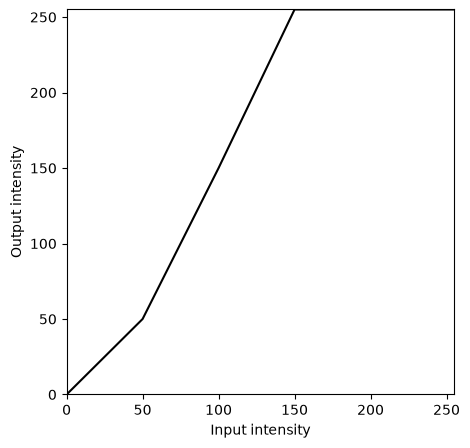

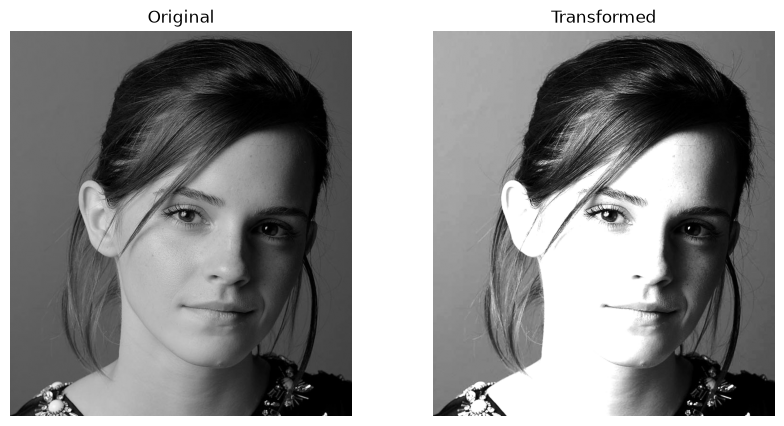

In [48]:
def intensity_transform(im, breakpoints):
    x_vals, y_vals = zip(*breakpoints)
    lut_table = np.interp(np.arange(256), x_vals, y_vals).astype(np.uint8)
    return cv2.LUT(im, lut_table)

face_input = cv2.imread("images/q1.jpeg", cv2.IMREAD_GRAYSCALE)
break_points = [(0, 0), (50, 50), (100, 150), (150, 255), (255, 255)]
face_output = intensity_transform(face_input, break_points)

x_plot, y_plot = zip(*break_points)
plt.figure(figsize=(5, 5))
plt.plot(x_plot, y_plot, color="black")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.show()

fig_side, axis_pair = plt.subplots(1, 2, figsize=(10, 5))
axis_pair[0].imshow(face_input, cmap="gray")
axis_pair[0].set_title("Original")
axis_pair[0].axis("off")
axis_pair[1].imshow(face_output, cmap="gray")
axis_pair[1].set_title("Transformed")
axis_pair[1].axis("off")
plt.show()

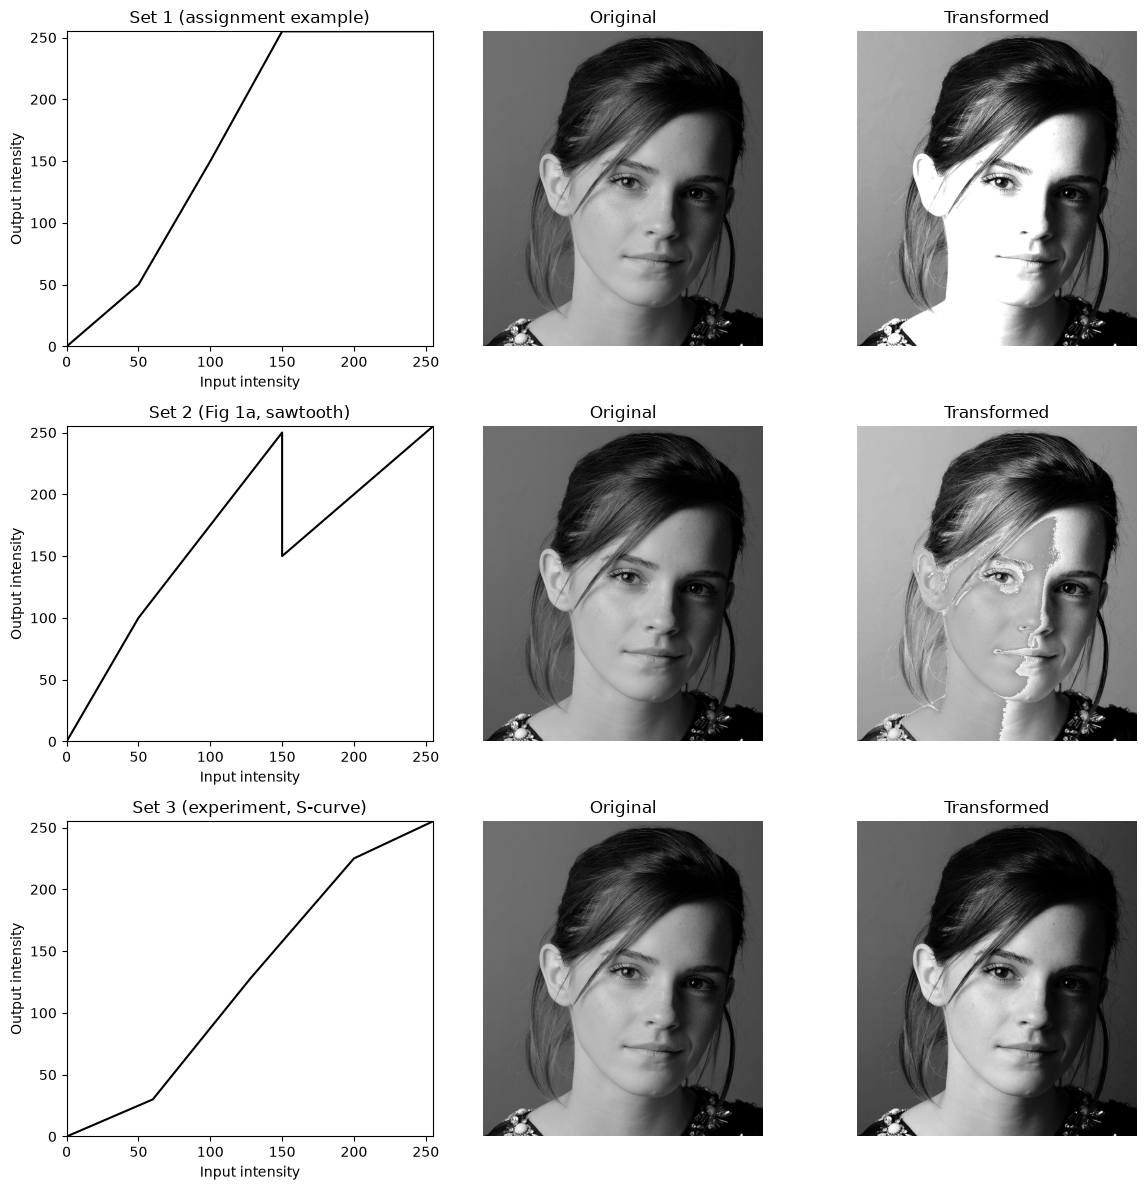

In [49]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    lut = np.zeros(256)
    for (x0, y0), (x1, y1) in zip(breakpoints, breakpoints[1:]):
        if x1 == x0:
            continue  # zero-width segment (vertical jump), skip
        idx = np.arange(x0, x1)
        lut[idx] = np.linspace(y0, y1, x1 - x0, endpoint=False)
    lut[255] = breakpoints[-1][1]
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return cv2.LUT(im, lut)

face_input = cv2.imread("images/q1.jpeg", cv2.IMREAD_GRAYSCALE)

breakpoint_sets = {
    "Set 1 (assignment example)": [(0, 0), (50, 50), (100, 150), (150, 255), (255, 255)],
    "Set 2 (Fig 1a, sawtooth)":    [(0, 0), (50, 100), (150, 250), (150, 150), (255, 255)],
    "Set 3 (experiment, S-curve)": [(0, 0), (60, 30), (128, 128), (200, 225), (255, 255)],
}

results = {}
for name, bp in breakpoint_sets.items():
    out = intensity_transform(face_input, bp)
    results[name] = (bp, out)

fig, axes = plt.subplots(len(results), 3, figsize=(12, 4 * len(results)))
for row, (name, (bp, out)) in enumerate(results.items()):
    x_plot, y_plot = zip(*bp)
    axes[row, 0].plot(x_plot, y_plot, color="black")
    axes[row, 0].set_xlim(0, 255)
    axes[row, 0].set_ylim(0, 255)
    axes[row, 0].set_title(name)
    axes[row, 0].set_xlabel("Input intensity")
    axes[row, 0].set_ylabel("Output intensity")

    axes[row, 1].imshow(face_input, cmap="gray")
    axes[row, 1].set_title("Original")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(out, cmap="gray")
    axes[row, 2].set_title("Transformed")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

Question 02


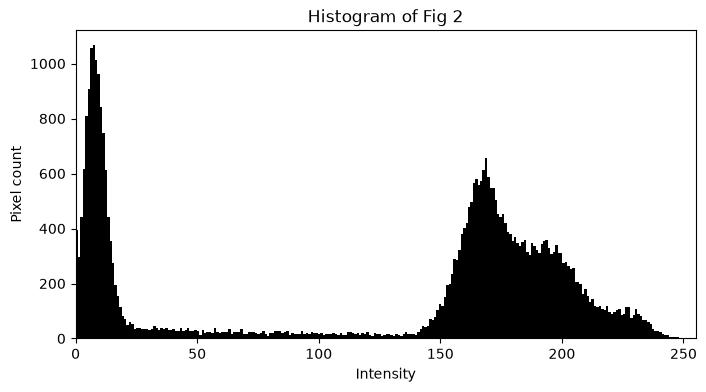

In [50]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

mri_input = cv2.imread("images/q2.jpeg", cv2.IMREAD_GRAYSCALE)

# plain histogram to know actual pixel intensity distribution of where white and gray matter is present
plt.figure(figsize=(8, 4))
plt.hist(mri_input.ravel(), bins=256, range=(0, 255), color="black")
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.title("Histogram of Fig 2")
plt.xlim(0, 255)
plt.show()

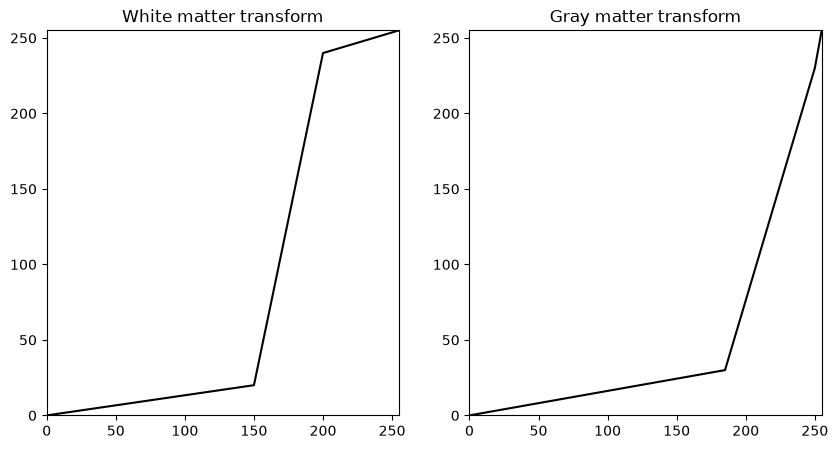

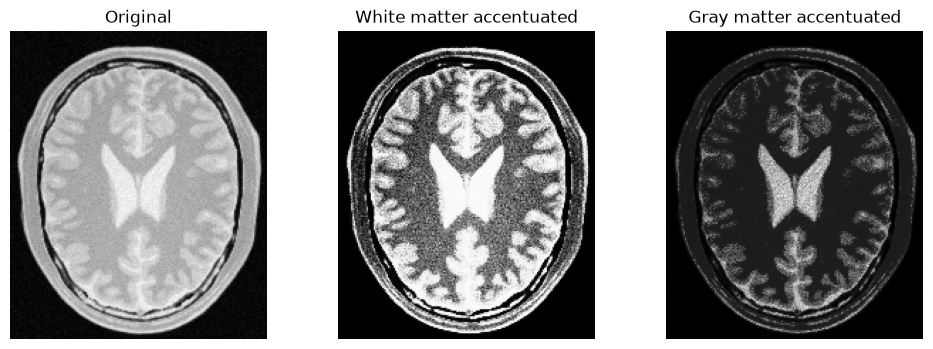

In [51]:
mri_input = cv2.imread("images/q2.jpeg", cv2.IMREAD_GRAYSCALE)

# white_breaks = [(0, 0), (150, 60), (190, 230), (255, 255)]
# gray_breaks = [(0, 0), (90, 40), (130, 220), (170, 255), (255, 255)]
white_breaks = [(0, 0), (150, 20), (200, 240), (255, 255)]
gray_breaks = [(0, 0), (185, 30), (250, 230), (255, 255)]  
white_result = intensity_transform(mri_input, white_breaks)
gray_result = intensity_transform(mri_input, gray_breaks)

x_white, y_white = zip(*white_breaks)
x_gray, y_gray = zip(*gray_breaks)

fig_curves, axis_curves = plt.subplots(1, 2, figsize=(10, 5))
axis_curves[0].plot(x_white, y_white, color="black")
axis_curves[0].set_title("White matter transform")
axis_curves[0].set_xlim(0, 255)
axis_curves[0].set_ylim(0, 255)
axis_curves[1].plot(x_gray, y_gray, color="black")
axis_curves[1].set_title("Gray matter transform")
axis_curves[1].set_xlim(0, 255)
axis_curves[1].set_ylim(0, 255)
plt.show()

fig_tissue, axis_tissue = plt.subplots(1, 3, figsize=(12, 4))
axis_tissue[0].imshow(mri_input, cmap="gray")
axis_tissue[0].set_title("Original")
axis_tissue[0].axis("off")
axis_tissue[1].imshow(white_result, cmap="gray")
axis_tissue[1].set_title("White matter accentuated")
axis_tissue[1].axis("off")
axis_tissue[2].imshow(gray_result, cmap="gray")
axis_tissue[2].set_title("Gray matter accentuated")
axis_tissue[2].axis("off")
plt.show()

Question 03


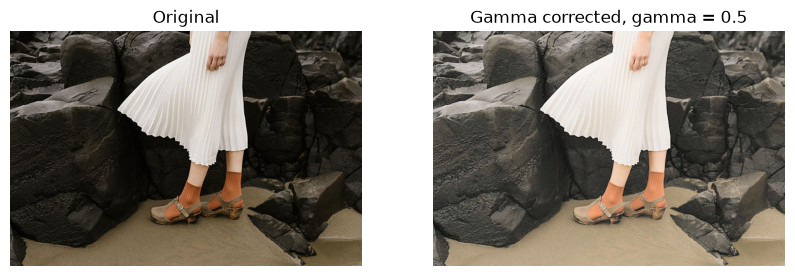

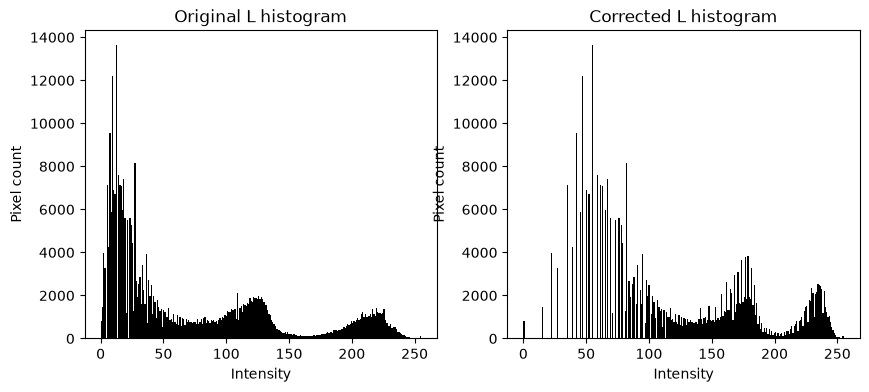

In [52]:
color_photo = cv2.imread("images/q3.jpeg")
lab_planes = cv2.cvtColor(color_photo, cv2.COLOR_BGR2LAB)
light_plane, a_plane, b_plane = cv2.split(lab_planes)

gamma_pick = 0.5
normalized_light = light_plane.astype(np.float32) / 255.0
corrected_light = np.power(normalized_light, gamma_pick) * 255.0
corrected_light = corrected_light.astype(np.uint8)

lab_corrected = cv2.merge([corrected_light, a_plane, b_plane])
photo_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)

fig_gamma, axis_gamma = plt.subplots(1, 2, figsize=(10, 5))
axis_gamma[0].imshow(cv2.cvtColor(color_photo, cv2.COLOR_BGR2RGB))
axis_gamma[0].set_title("Original")
axis_gamma[0].axis("off")
axis_gamma[1].imshow(cv2.cvtColor(photo_corrected, cv2.COLOR_BGR2RGB))
axis_gamma[1].set_title(f"Gamma corrected, gamma = {gamma_pick}")
axis_gamma[1].axis("off")
plt.show()

fig_hist, axis_hist = plt.subplots(1, 2, figsize=(10, 4))
axis_hist[0].hist(light_plane.ravel(), bins=256, range=(0, 255), color="black")
axis_hist[0].set_title("Original L histogram")
axis_hist[0].set_xlabel("Intensity")
axis_hist[0].set_ylabel("Pixel count")
axis_hist[1].hist(corrected_light.ravel(), bins=256, range=(0, 255), color="black")
axis_hist[1].set_title("Corrected L histogram")
axis_hist[1].set_xlabel("Intensity")
axis_hist[1].set_ylabel("Pixel count")
plt.show()

Question 04


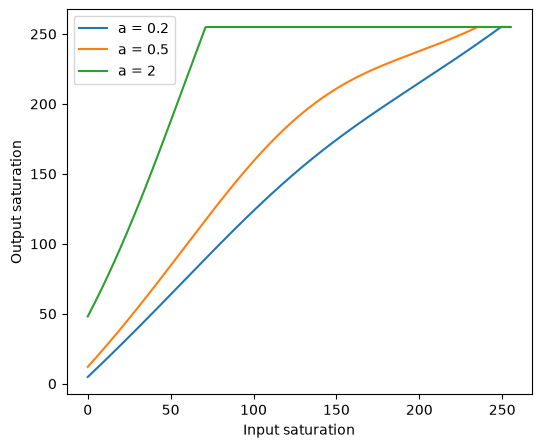

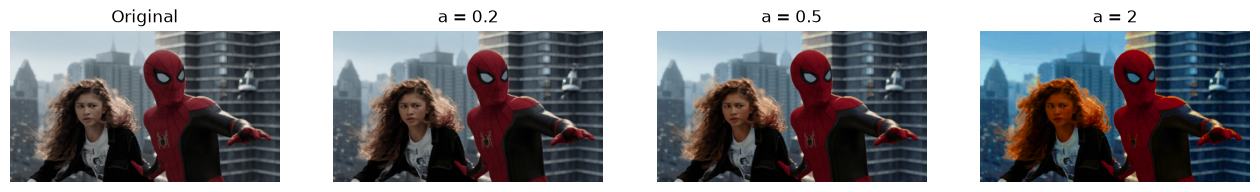

In [53]:
street_photo = cv2.imread("images/q4.jpeg")
hsv_planes = cv2.cvtColor(street_photo, cv2.COLOR_BGR2HSV)
hue_plane, sat_plane, val_plane = cv2.split(hsv_planes)

sigma_fixed = 70
sat_axis = np.arange(256)

def boost_saturation(sat_channel, alpha_pick):
    sat_float = sat_channel.astype(np.float32)
    bump = alpha_pick * 128 * np.exp(-((sat_float - 128) ** 2) / (2 * sigma_fixed ** 2))
    boosted = np.minimum(sat_float + bump, 255)
    return boosted.astype(np.uint8)

alpha_trials = [0.2, 0.5, 2]
result_photos = []
for alpha_pick in alpha_trials:
    sat_boosted = boost_saturation(sat_plane, alpha_pick)
    hsv_boosted = cv2.merge([hue_plane, sat_boosted, val_plane])
    photo_boosted = cv2.cvtColor(hsv_boosted, cv2.COLOR_HSV2BGR)
    result_photos.append(photo_boosted)

fig_curve = plt.figure(figsize=(6, 5))
for alpha_pick in alpha_trials:
    bump_curve = alpha_pick * 128 * np.exp(-((sat_axis - 128) ** 2) / (2 * sigma_fixed ** 2))
    curve_vals = np.minimum(sat_axis + bump_curve, 255)
    plt.plot(sat_axis, curve_vals, label=f"a = {alpha_pick}")
plt.xlabel("Input saturation")
plt.ylabel("Output saturation")
plt.legend()
plt.show()

fig_compare, axis_compare = plt.subplots(1, 4, figsize=(16, 4))
axis_compare[0].imshow(cv2.cvtColor(street_photo, cv2.COLOR_BGR2RGB))
axis_compare[0].set_title("Original")
axis_compare[0].axis("off")
for slot, alpha_pick, boosted_photo in zip(range(1, 4), alpha_trials, result_photos):
    axis_compare[slot].imshow(cv2.cvtColor(boosted_photo, cv2.COLOR_BGR2RGB))
    axis_compare[slot].set_title(f"a = {alpha_pick}")
    axis_compare[slot].axis("off")
plt.show()

The most pleasing alpha value is 2


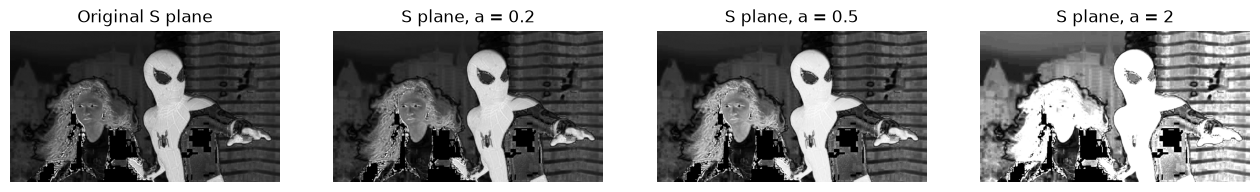

In [54]:
#lets isolate the saturation plane and show the effect of boosting saturation on it alone, without the hue and value planes

fig_sat_only, axis_sat_only = plt.subplots(1, 4, figsize=(16, 4))
axis_sat_only[0].imshow(sat_plane, cmap="gray")
axis_sat_only[0].set_title("Original S plane")
axis_sat_only[0].axis("off")
for slot, alpha_pick in zip(range(1, 4), alpha_trials):
    sat_preview = boost_saturation(sat_plane, alpha_pick)
    axis_sat_only[slot].imshow(sat_preview, cmap="gray")
    axis_sat_only[slot].set_title(f"S plane, a = {alpha_pick}")
    axis_sat_only[slot].axis("off")
plt.show()